# Liệu thói quen sinh hoạt có ảnh hưởng gì đến khả năng mắc bệnh trầm cảm không?

Tiến hành đọc dữ liệu để xem trong dữ liệu có những yếu tố thói quen sinh hoạt nào liên quan

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
sns.set_style("whitegrid")
df = pd.read_csv("data_final.csv")

Các yếu tố được xem xét bao gồm:
- Thói quen ăn uống (Dietary Habits)
- Thời gian học tập/làm việc (Work/Study Hours)
- Thời lượng ngủ (Sleep Duration)

## Câu hỏi nhỏ
I. Phân tích từng yếu tố đơn lẻ
- Thói quen ăn uống có làm tăng nguy cơ trầm cảm không?
- Số giờ làm/học có liên quan đến trầm cảm không?
- Thời lượng ngủ ảnh hưởng thế nào đến trầm cảm?

II. Phân tích hai yếu tố kết hợp
- Sự kết hợp hai yếu tố sinh hoạt mang lại nguy cơ mắc bệnh Trầm cảm (Depression) lớn hơn đáng kể so với tác động độc lập không?

III. Phân tích ba yếu tố kết hợp
- Càng nhiều thói quen xấu thì nguy cơ trầm cảm có càng cao không?



### I. Phân tích từng yếu tố đơn lẻ

### Câu 1: Thói quen ăn uống có làm tăng nguy cơ trầm cảm không?

Mục tiêu của phân tích này là kiểm tra xem thói quen ăn uống (Dietary Habits)
có liên quan đến tình trạng trầm cảm (Depression) hay không.

Nếu chế độ ăn không lành mạnh có tỷ lệ trầm cảm cao hơn,
điều đó cho thấy thói quen ăn uống có thể là một yếu tố ảnh hưởng đến sức khỏe tinh thần.

,Total Sample,Depression,No Depression
Dietary Habits,,,
Healthy,44726,5275,39451
Moderate,49675,8221,41454
Unhealthy,46207,12040,34167


<Figure size 700x500 with 0 Axes>

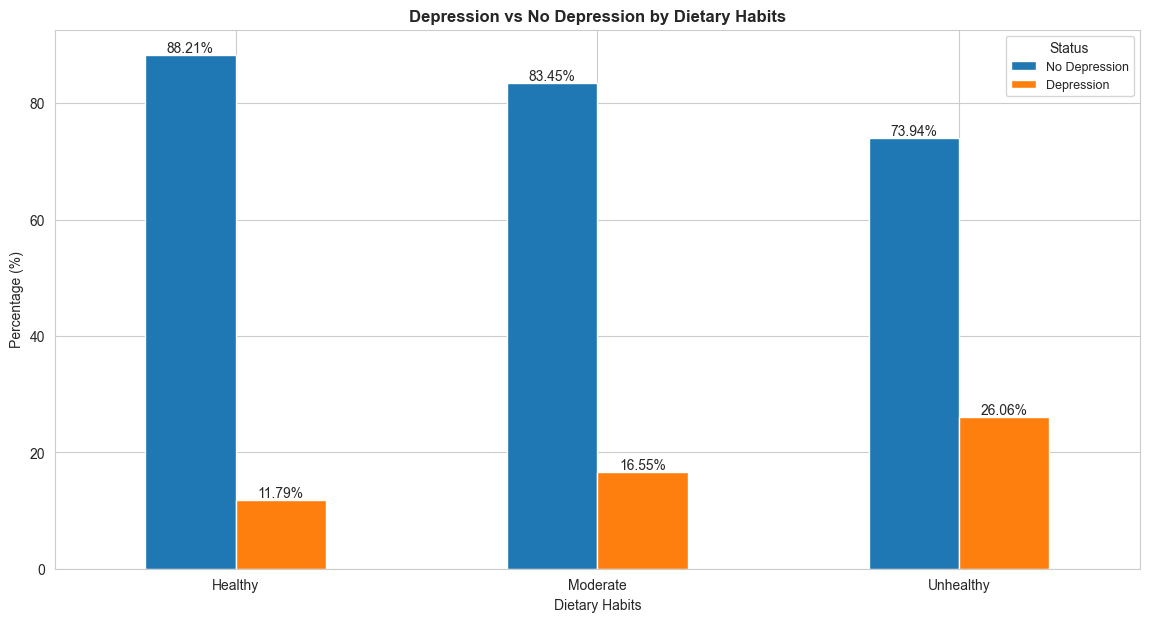

In [4]:
sample_table = df.groupby('Dietary Habits')['Depression'].agg(['count','sum'])
sample_table.columns = ['Total Sample','Depression']
sample_table['No Depression'] = sample_table['Total Sample'] - sample_table['Depression']

# sắp xếp thứ tự
order = ['Healthy','Moderate','Unhealthy']
sample_table = sample_table.reindex(order)

display(sample_table)
plt.figure(figsize=(7,5))

# tính tỷ lệ % cho cả 2 nhóm
diet_rate = pd.crosstab(df['Dietary Habits'], df['Depression'], normalize='index') * 100

diet_rate.columns = ['No Depression', 'Depression']

# vẽ biểu đồ
ax = diet_rate.plot(kind='bar', figsize=(14,7))

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center',
                va='bottom')

plt.title("Depression vs No Depression by Dietary Habits", fontweight='bold')
plt.xlabel("Dietary Habits")
plt.ylabel("Percentage (%)")
plt.legend(title="Status", title_fontsize=10, fontsize=9)
plt.xticks(rotation=0)
plt.savefig('h1.png')
plt.show()

### Nhận xét
Biểu đồ cho thấy trong cả ba nhóm thói quen ăn uống, tỷ lệ không trầm cảm vẫn chiếm đa số. Mặc dù tỷ lệ trầm cảm có xu hướng tăng từ nhóm Healthy (11.79%) lên Moderate (16.55%) và cao nhất ở Unhealthy (26.06%), nhưng sự khác biệt này không quá lớn khi so với tỷ lệ không trầm cảm trong mỗi nhóm.

Điều này cho thấy thói quen ăn uống có thể có liên quan đến trầm cảm, tuy nhiên không phải là yếu tố quyết định duy nhất. Nhiều yếu tố khác như giấc ngủ, khối lượng công việc hoặc các yếu tố tâm lý – xã hội cũng có thể đóng vai trò quan trọng trong nguy cơ trầm cảm.


## Câu 2: Số giờ làm/học có liên quan đến trầm cảm không?

Mục tiêu của phân tích này là kiểm tra xem số giờ làm việc hoặc học tập mỗi ngày (Work/Study Hours)
có liên quan đến tình trạng trầm cảm (Depression) hay không.

Nếu những người bị trầm cảm có xu hướng làm việc/học tập nhiều giờ hơn,
điều đó có thể cho thấy áp lực học tập hoặc công việc là một yếu tố góp phần
làm tăng nguy cơ trầm cảm.

Trong đó cột Work/Study Hours được chia thành các khoảng giá trị (binning) để dễ phân tích và so sánh. Cụ thể:

- 0–5 giờ → Low

- 5–8 giờ → Medium

- 8–12 giờ → High

In [3]:
bins = [0, 5, 8, 12]
labels = ['Low', 'Medium', 'High']

df['Work/Study Hours'] = pd.cut(
    df['Work/Study Hours'],
    bins=bins,
    labels=labels,
    include_lowest=True
)
df.to_csv("data_final.csv", index=False)

Sample size by Work/Study Hours:


,No Depression,Depression
Work/Study Hours,,
Low,54053,6244
Medium,23147,6046
High,37872,13246


<Figure size 1400x700 with 0 Axes>

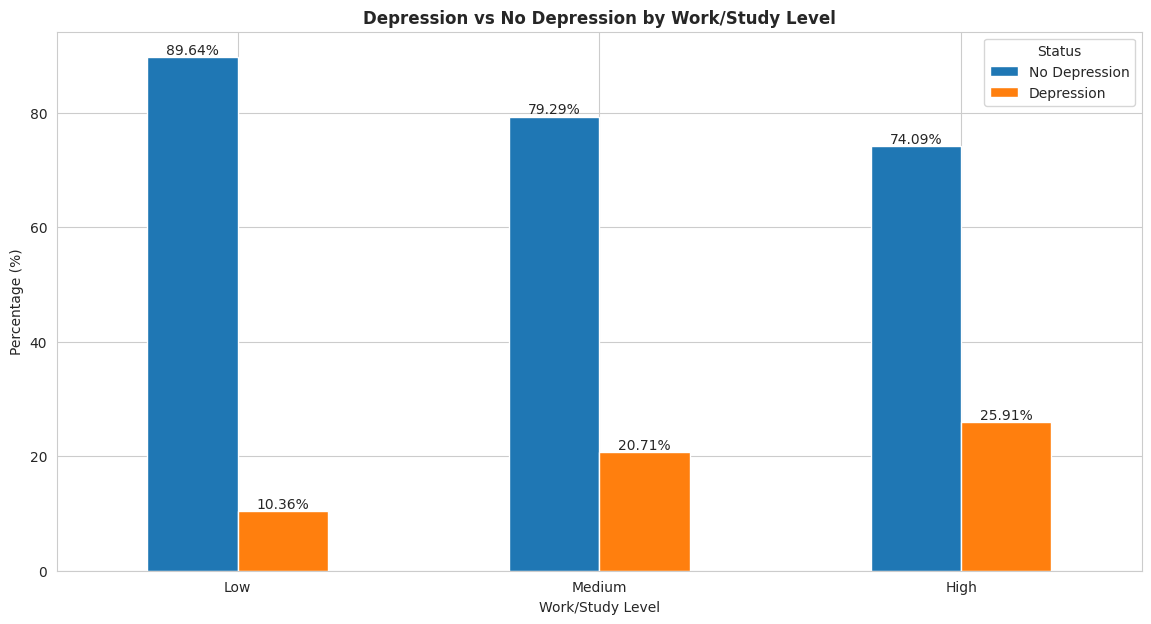

In [4]:
# tính tỷ lệ % cho cả 2 nhóm
work_dep = pd.crosstab(df['Work/Study Hours'], df['Depression'], normalize='index') * 100

# đổi tên cột
work_dep.columns = ['No Depression', 'Depression']
sample_table = pd.crosstab(df['Work/Study Hours'], df['Depression'])

sample_table.columns = ['No Depression', 'Depression']

print("Sample size by Work/Study Hours:")
display(sample_table)
plt.figure(figsize=(14,7))

ax = work_dep.plot(kind='bar', figsize=(14,7))

# thêm % trên đầu cột
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center',
                va='bottom')

plt.title('Depression vs No Depression by Work/Study Level', fontweight='bold')
plt.xlabel('Work/Study Level')
plt.ylabel('Percentage (%)')
plt.legend(title="Status")
plt.xticks(rotation=0)
plt.savefig('h2.png')
plt.show()

### Nhận xét

Biểu đồ cho thấy sự khác biệt về tỷ lệ trầm cảm giữa các mức thời gian làm việc/học tập. Ở cả ba mức, tỷ lệ không trầm cảm vẫn chiếm đa số, tuy nhiên tỷ lệ trầm cảm có xu hướng tăng dần khi thời gian làm việc/học tập tăng lên.

Cụ thể, ở nhóm Low, tỷ lệ trầm cảm chỉ 10.36%, trong khi 89.64% không bị trầm cảm. Ở mức Medium, tỷ lệ trầm cảm tăng lên 20.71%, đồng thời tỷ lệ không trầm cảm giảm xuống 79.29%. Đến mức High, tỷ lệ trầm cảm tiếp tục tăng lên 25.91%, trong khi tỷ lệ không trầm cảm còn 74.09%.

Xu hướng này cho thấy những người dành nhiều thời gian cho công việc hoặc học tập có xu hướng có tỷ lệ trầm cảm cao hơn, mặc dù phần lớn vẫn thuộc nhóm không trầm cảm.


## Câu 3: Thời lượng ngủ ảnh hưởng thế nào đến trầm cảm?

Mục tiêu của phân tích này là kiểm tra xem thời lượng ngủ (Sleep Duration)
có ảnh hưởng đến tình trạng trầm cảm (Depression) hay không?

Liệu những người ngủ quá ít hoặc không đủ giấc có thể dễ gặp
các vấn đề về tâm lý như căng thẳng hoặc trầm cảm hay không?

Sample size by Sleep Duration:


,No Depression,Depression
Sleep Duration Label,,
1: <4 hours,17,2
2: 4 - 6 hours,56493,14405
3: 6 - 8 hours,10,2
4: 7 - 9 hours,30371,6588
5: >9 hours,28181,4539


<Figure size 1400x700 with 0 Axes>

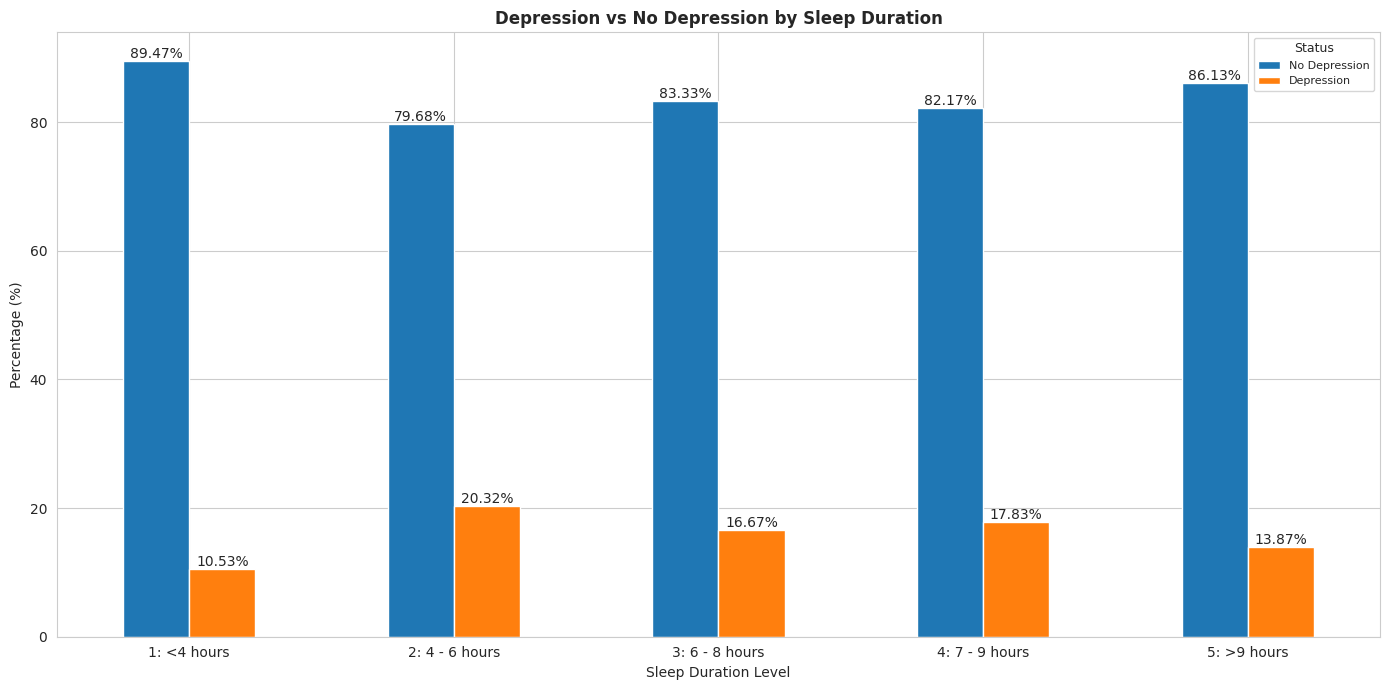

In [5]:
# 1. Mapping mức ngủ
sleep_labels = {
    1: "1: <4 hours",
    2: "2: 4 - 6 hours",
    3: "3: 6 - 8 hours",
    4: "4: 7 - 9 hours",
    5: "5: >9 hours"
}

df['Sleep Duration Label'] = df['Sleep Duration'].map(sleep_labels)

order = list(sleep_labels.values())

# 2. Tính tỷ lệ % cho 2 nhóm
sleep_dep = pd.crosstab(
    df['Sleep Duration Label'],
    df['Depression'],
    normalize='index'
) * 100

sleep_dep.columns = ['No Depression', 'Depression']

# 3. In số lượng mẫu ra ngoài
sample_table = pd.crosstab(df['Sleep Duration Label'], df['Depression']).reindex(order)

sample_table.columns = ['No Depression', 'Depression']

print("Sample size by Sleep Duration:")
display(sample_table)


# 4. Vẽ biểu đồ
plt.figure(figsize=(14,7))

ax = sleep_dep.loc[order].plot(kind='bar', figsize=(14,7))

# 5. Thêm % trên cột
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center',
                va='bottom')

plt.title('Depression vs No Depression by Sleep Duration', fontweight='bold')
plt.xlabel('Sleep Duration Level')
plt.ylabel('Percentage (%)')
plt.legend(title="Status", loc='upper right',title_fontsize=9, fontsize=8)

plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig('h3.png')
plt.show()

### Nhận xét

Biểu đồ cho thấy sự khác biệt về tỷ lệ trầm cảm giữa các mức thời lượng ngủ. Ở tất cả các nhóm, tỷ lệ không trầm cảm vẫn chiếm đa số, tuy nhiên tỷ lệ trầm cảm có sự thay đổi khá nhiều theo thời lượng ngủ.

Cụ thể, nhóm ngủ 4–6 giờ (Thấp) có tỷ lệ trầm cảm cao nhất (20.32%), tiếp theo là nhóm 7–9 giờ (Lý tưởng) với 17.83%. Trong khi đó, nhóm ngủ 6–8 giờ (Trung bình) có tỷ lệ trầm cảm thấp (16.67%). Nhóm ngủ rất ít (<4 giờ) và cao (>9 giờ) có tỷ lệ trầm cảm ở mức trung bình, lần lượt là 10.53% (do mẫu quá ít) và 13.87%.

Kết quả này cho thấy thời lượng ngủ trung bình khoảng 6–8 giờ có xu hướng liên quan đến tỷ lệ trầm cảm thấp hơn, trong khi ngủ quá ít hoặc thời gian ngủ không ổn định có thể đi kèm với tỷ lệ trầm cảm cao hơn.

### Nhận xét phần I

Khi phân tích từng yếu tố riêng lẻ như chế độ ăn uống, thời gian làm việc/học tập và thời lượng ngủ, có thể thấy tỷ lệ trầm cảm có sự thay đổi giữa các nhóm. Tuy nhiên, mức tăng này không quá lớn, và trong mọi trường hợp tỷ lệ không trầm cảm vẫn chiếm đa số.

Điều này cho thấy mỗi yếu tố riêng lẻ chỉ làm thay đổi tỷ lệ trầm cảm ở mức nhẹ, và có thể trầm cảm chịu ảnh hưởng từ sự kết hợp của nhiều yếu tố.


### II. Phân tích hai yếu tố kết hợp

## Câu 4: Sự kết hợp hai yếu tố sinh hoạt mang lại nguy cơ mắc bệnh Trầm cảm (Depression) lớn hơn đáng kể so với tác động độc lập không?

Mục tiêu của phân tích này là kiểm tra xem sự kết hợp giữa các cặp thói quen sinh hoạt bao gồm: thời lượng ngủ (Sleep Duration), số giờ làm việc/học tập (Work/Study Hours) và thói quen ăn uống (Dietary Habits) có tạo ra tác động cộng hưởng đến tình trạng trầm cảm (Depression).

Liệu những người làm việc/học tập với cường độ cao, kết hợp với việc thiếu ngủ và ăn uống không lành mạnh, thì nguy cơ rơi vào trầm cảm có tăng vọt (hiệu ứng khuếch đại) so với khi họ chỉ mắc phải một trong những thói quen xấu này hay không?

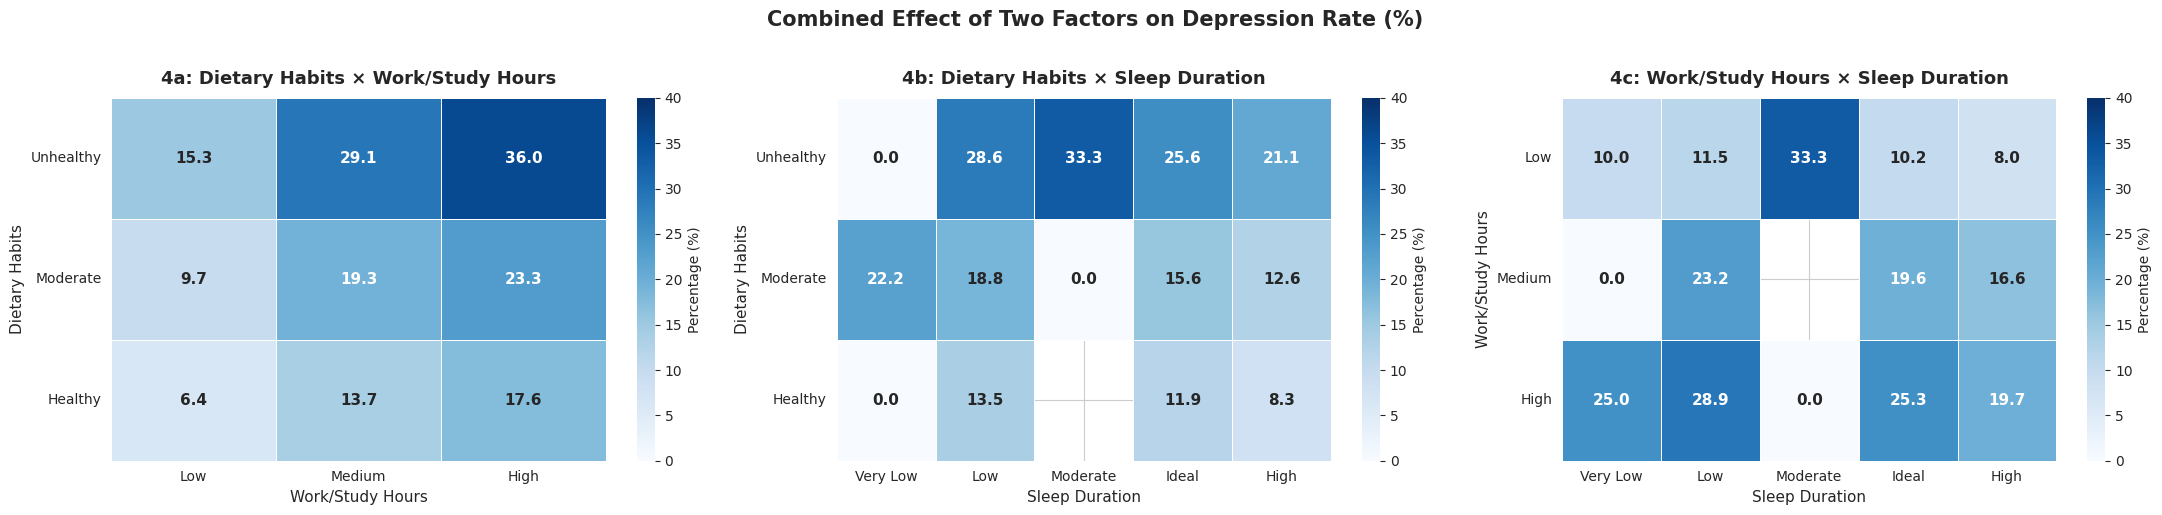

In [6]:
sleep_labels = {
    1: 'Very Low',
    2: 'Low',
    3: 'Moderate',
    4: 'Ideal',
    5: 'High'
}

df['WSH_group'] = df['Work/Study Hours']
df['Sleep_label'] = df['Sleep Duration'].map(sleep_labels)

diet_order  = ['Unhealthy', 'Moderate', 'Healthy']
wsh_order   = ['Low', 'Medium', 'High']
sleep_order = list(sleep_labels.values())

# Gom nhóm dữ liệu và tính tỷ lệ người mắc bệnh Trầm cảm (% Depression)
pivot_4a = (df.groupby(['Dietary Habits', 'WSH_group'], observed=True)['Depression']
              .mean().unstack()
              .reindex(index=diet_order, columns=wsh_order) * 100)

pivot_4b = (df.groupby(['Dietary Habits', 'Sleep_label'])['Depression']
              .mean().unstack()
              .reindex(index=diet_order, columns=sleep_order) * 100)

pivot_4c = (df.groupby(['WSH_group', 'Sleep_label'], observed=True)['Depression']
              .mean().unstack()
              .reindex(index=wsh_order, columns=sleep_order) * 100)

# Vẽ biểu đồ
fig, axes = plt.subplots(1, 3, figsize=(22, 5))
fig.suptitle('Combined Effect of Two Factors on Depression Rate (%)',
             fontsize=15, fontweight='bold', y=1.02)

vmin, vmax = 0, 40

def draw_hmap(ax, data, title, xlabel, ylabel):
    sns.heatmap(data, annot=True, fmt='.1f', cmap='Blues',
                vmin=vmin, vmax=vmax, linewidths=0.5, linecolor='white',
                ax=ax, annot_kws={'size': 11, 'weight': 'bold'},
                cbar_kws={'label': 'Percentage (%)'})
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.tick_params(axis='x', rotation=0)
    ax.tick_params(axis='y', rotation=0)

draw_hmap(axes[0], pivot_4a, '4a: Dietary Habits × Work/Study Hours', 'Work/Study Hours', 'Dietary Habits')
draw_hmap(axes[1], pivot_4b, '4b: Dietary Habits × Sleep Duration', 'Sleep Duration', 'Dietary Habits')
draw_hmap(axes[2], pivot_4c, '4c: Work/Study Hours × Sleep Duration', 'Sleep Duration', 'Work/Study Hours')

plt.tight_layout()
plt.savefig('h5.png')
plt.show()

### Nhận xét:
Các biểu đồ heatmap cho thấy tỷ lệ trầm cảm luôn đạt mức cao nhất khi các thói quen sinh hoạt tiêu cực xuất hiện cùng lúc:
* Biểu đồ 4a (Ăn uống × Giờ làm/học):  Nhóm có chế độ ăn kém (Unhealthy) và cường độ làm việc cao (High) có tỷ lệ trầm cảm cực kỳ cao, lên tới 36.0%. Ngược lại, nhóm có lối sống lành mạnh nhất (ăn Healthy, làm việc Low) chỉ ở mức 6.4%.
* Biểu đồ 4b (Ăn uống × Giờ ngủ): Sự kết hợp giữa chế độ ăn Unhealthy và thời lượng ngủ Thấp/TB đẩy rủi ro trầm cảm lên mức 28.6% – 33.3%. Trong khi đó, người ăn Healthy và ngủ Cao chỉ ghi nhận tỷ lệ 8.3%.
* Biểu đồ 4c (Giờ làm/học × Giờ ngủ): Nhóm người vắt kiệt sức với cường độ làm việc High nhưng ngủ Thấp có tỷ lệ trầm cảm là 28.9%, cao gần gấp 3 lần so với những người làm việc cường độ Low và ngủ Lý tưởng (chỉ 10.2%).

Kết luận: Sự kết hợp giữa hai yếu tố sinh hoạt xấu mang lại rủi ro mắc bệnh Trầm cảm lớn hơn đáng kể so với tổng các tác động độc lập. Các thói quen này không hoạt động riêng lẻ, mà chúng tương tác và làm trầm trọng thêm hậu quả của nhau đẩy người bệnh vào nguy cơ suy sụp tinh thần với tỷ lệ cao.

### III. Phân tích ba yếu tố kết hợp

## Câu 5: Càng nhiều thói quen xấu thì nguy cơ trầm cảm có càng cao không?

Mục tiêu của phân tích này là kiểm tra xem số lượng thói quen sinh hoạt không lành mạnh (Bad Habits)
có ảnh hưởng đến tình trạng trầm cảm (Depression) hay không.

Trong phân tích này, thói quen xấu được xác định dựa trên ba yếu tố trong dữ liệu:

- Ngủ quá ít (Sleep Duration ≤ mức thấp, tương ứng dưới khoảng 6 giờ).

- Thời gian học tập/làm việc cao (Work/Study Hours = High).

- Chế độ ăn uống không lành mạnh (Dietary Habits = Unhealthy).

Phân tích này nhằm trả lời câu hỏi: Liệu khi số lượng thói quen xấu tăng lên, nguy cơ mắc trầm cảm có tăng theo hay không?

,Number of Bad Habits,No Depression,Depression
0,0,90.675720,9.324280
1,1,84.965546,15.034454
2,2,75.047562,24.952438
3,3,60.818975,39.181025


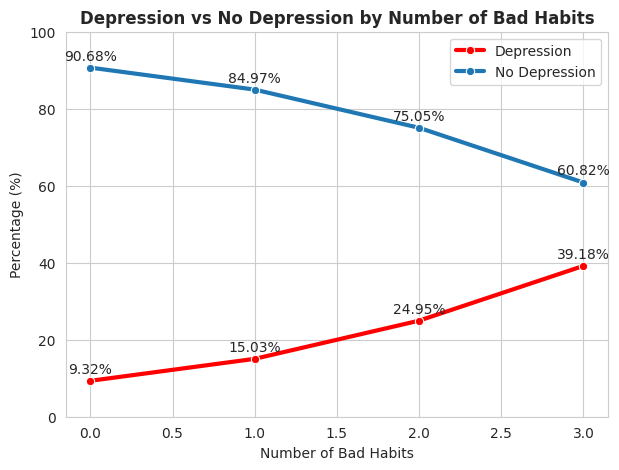

In [7]:
# 1. Tạo các biến thói quen xấu
df['bad_sleep'] = (df['Sleep Duration'] <= 2).astype(int)
df['bad_work'] = (df['Work/Study Hours'] == 'High').astype(int)
df['bad_diet'] = (df['Dietary Habits'] == 'Unhealthy').astype(int)

# 2. Tổng số thói quen xấu
df['bad_habits_count'] = (
    df['bad_sleep'] +
    df['bad_work'] +
    df['bad_diet']
)
# 3. Tính tỷ lệ % cho cả 2 nhóm
habit_analysis = pd.crosstab(
    df['bad_habits_count'],
    df['Depression'],
    normalize='index'
) * 100

habit_analysis = habit_analysis.reset_index()
habit_analysis.columns = ['Number of Bad Habits','No Depression','Depression']

display(habit_analysis)


# 4. Vẽ biểu đồ 2 đường
plt.figure(figsize=(7,5))

sns.lineplot(
    data=habit_analysis,
    x='Number of Bad Habits',
    y='Depression',
    marker='o',
    linewidth=3,
    color='red',
    label='Depression'
)

sns.lineplot(
    data=habit_analysis,
    x='Number of Bad Habits',
    y='No Depression',
    marker='o',
    linewidth=3,
    label='No Depression'
)

# thêm % trên từng điểm
for x, y in zip(habit_analysis['Number of Bad Habits'], habit_analysis['Depression']):
    plt.text(x, y + 2, f'{y:.2f}%', ha='center')

for x, y in zip(habit_analysis['Number of Bad Habits'], habit_analysis['No Depression']):
    plt.text(x, y + 2, f'{y:.2f}%', ha='center')

plt.title('Depression vs No Depression by Number of Bad Habits', fontweight='bold')
plt.xlabel('Number of Bad Habits')
plt.ylabel('Percentage (%)')
plt.ylim(0,100)

plt.savefig('h5.png')
plt.show()

### Nhận xét

Hai đường trong biểu đồ thể hiện xu hướng nghịch chiều rõ ràng giữa tỷ lệ trầm cảm và không trầm cảm khi số lượng thói quen xấu tăng lên. Khi không có thói quen xấu, tỷ lệ trầm cảm chỉ 9.32%, trong khi tỷ lệ không trầm cảm chiếm tới 90.68%. Khi xuất hiện 1 thói quen xấu, tỷ lệ trầm cảm tăng lên 15.03% và tỷ lệ không trầm cảm giảm xuống 84.97%.

Xu hướng này tiếp tục rõ hơn khi số thói quen xấu tăng lên. Với 2 thói quen xấu, tỷ lệ trầm cảm tăng lên 24.95%, trong khi tỷ lệ không trầm cảm giảm xuống 75.05%. Đến khi có 3 thói quen xấu, tỷ lệ trầm cảm tăng mạnh lên 39.18%, còn tỷ lệ không trầm cảm giảm xuống 60.82%.

Điều này cho thấy khi các thói quen sinh hoạt không lành mạnh tích lũy nhiều hơn, tỷ lệ trầm cảm có xu hướng tăng lên đáng kể, đồng thời tỷ lệ không trầm cảm giảm dần. Tuy nhiên vẫn có nhóm không trầm cảm vẫn chiếm đa số.

## Kết luận tổng thể

Kết quả phân tích cho thấy các thói quen sinh hoạt có mối liên hệ nhất định với nguy cơ trầm cảm.

Khi xem xét từng yếu tố riêng lẻ, mức độ khác biệt không quá lớn. Ta thấy những người có chế độ ăn uống kém lành mạnh, thời gian làm việc/học tập cao hoặc thời lượng ngủ không phù hợp thường làm tăng tỷ lệ trầm cảm mặc dù không đáng kể so với nhóm người không bị trầm cảm.

Tuy nhiên, khi nhiều thói quen xấu xuất hiện đồng thời, tỷ lệ trầm cảm tăng rõ rệt. Điều này cho thấy sự kết hợp của nhiều thói quen sinh hoạt không lành mạnh có thể làm gia tăng nguy cơ trầm cảm mạnh hơn so với từng yếu tố riêng lẻ.
